# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [1]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [270]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.


$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [271]:
from numpy.linalg import norm

class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        loss = np.pow(norm(np.dot(X, w) - y), 2) / X.shape[0]
        return loss
        
        # Вычислите значение функции потерь при помощи X, y и w и верните его

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        
        grad = 2 / X.shape[0] * X.T.dot(np.dot(X, w) - y)
        return grad
        
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [272]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [273]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    massive_w = [w_init.copy()]
    w_new = w_init.copy()
    
    for _ in range(n_iterations):
        grad = loss.calc_grad(X, y, w_init)
        w_new = w_init - lr * grad
        massive_w.append(w_new.copy())
        w_init = w_new.copy()
    
    return massive_w

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [274]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [275]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.5891768045025
0.8670644395649494


In [276]:
test = gradient_descent(w_init, X, y, loss, 0.1, 100)
print(test[0], test[-1])

[0.62074297 1.79288146] [-4.57187575e+115  5.99891930e+117]


In [277]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(35, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

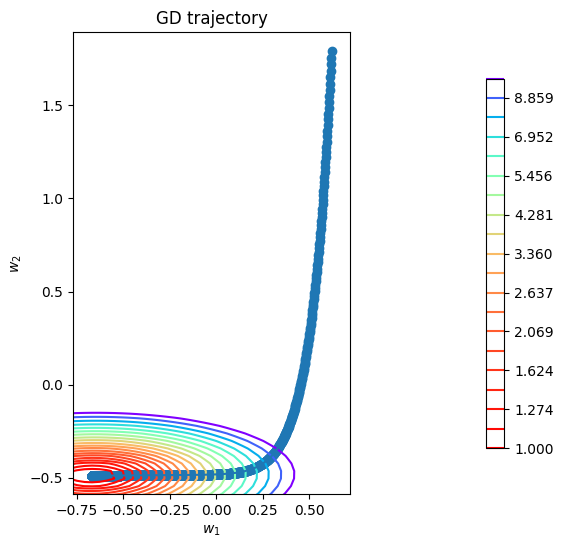

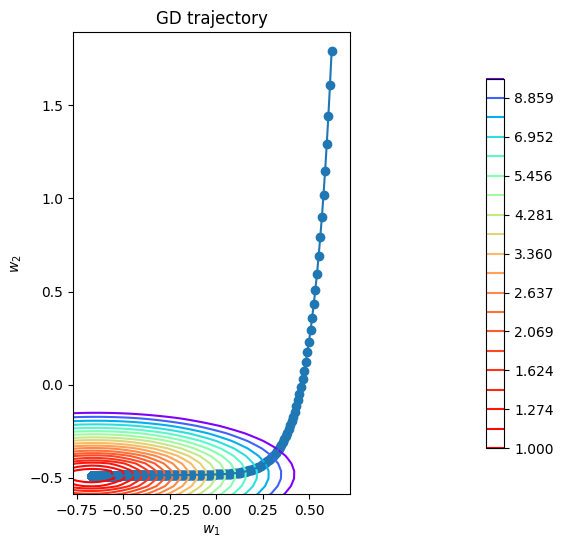

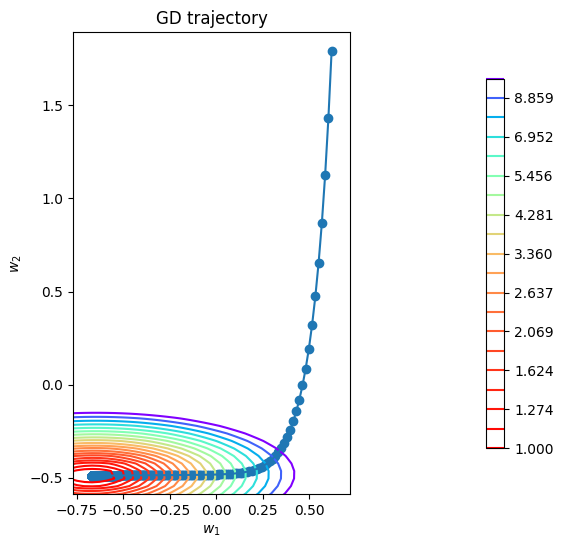

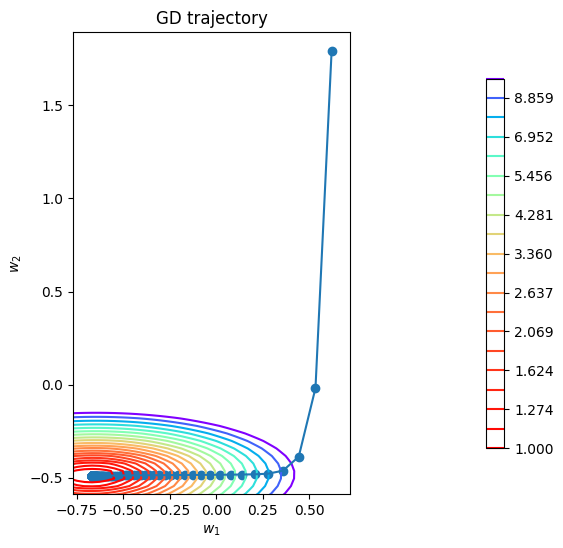

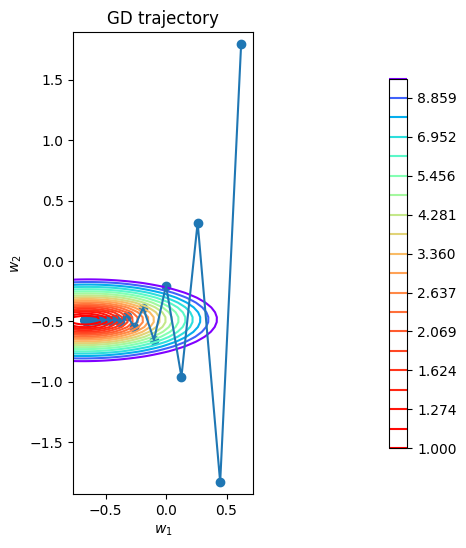

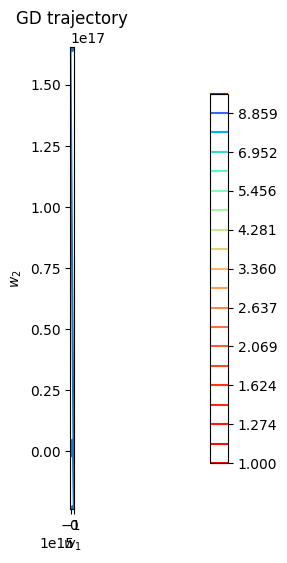

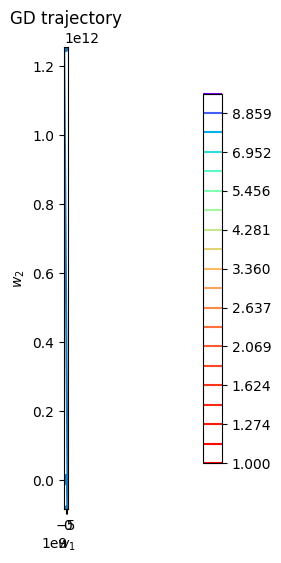

In [278]:
lr_massive = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]

for lr in lr_massive:
    w_massive = gradient_descent(w_init, X, y, loss, lr, int(1 / lr))
    plot_gd(w_massive, X, y, loss)

__Выводы__: для более эстетичной отрисовки я позволил себе изменять кол-во иттераций спуска, задавая её динамиически. Изначально если этого не сделать, картинки скомканные получаются.

Параметр шага влияет на то, как сильно будет колбасить траекторию нашего спуска. Заметим, что при первых трех значения эта траектория плавная, без резких скачков. А вот уже начиная с 4 значения, т.е. 0.005 и так далее наблюдаеются значительные скачки.

Видим, что на последних двух спусках происходит что-то странное: видимо из-за большой (для этой задачи) длины шага мы каак-то то ли сразу приходим в минимум, то ли попросту с самого начала его проскакиваем и болтаемся между двумя точками.

Попробую на наглядном примере показать, что при lr=0.05 или 0.1 градиентный спуск работает крайне плохо

In [279]:
print(f'Ошибка при полной сходимости ГД и достижения минимума: {loss.calc_loss(X, y, gradient_descent(w_init, X, y, loss, 0.001, 100)[-1])}')
print(f'Ошибка при lr=0.05: {loss.calc_loss(X, y, gradient_descent(w_init, X, y, loss, 0.05, 100)[-1])}')
print(f'Ошибка при lr=0.1: {loss.calc_loss(X, y, gradient_descent(w_init, X, y, loss, 0.1, 100)[-1])}')
# print(loss.calc_loss(X, y, w_list[0]))
# print(loss.calc_loss(X, y, w_list[-1]))

Ошибка при полной сходимости ГД и достижения минимума: 1.4574842940443404
Ошибка при lr=0.05: 1.7060638617007164e+171
Ошибка при lr=0.1: 2.867494833868978e+237


Видно, насколько сильно ошибка растёт при увеличении длины шага - значит мы тупо проскакиваем минимум и начинаем расходиться.

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [280]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    
    w_list = [w_init.copy()]
    w_new = w_init.copy()
    
    for _ in range(n_iterations):
        index = np.random.choice(X.shape[0], size=batch_size, replace=False)
        batch = X[index]
        y_batch = y[index]
        grad = loss.calc_grad(batch, y_batch, w_new)
        w_new = w_new - lr * grad
        w_list.append(w_new)
        
    return w_list
        

Проверим работоспособность алгоритма

In [282]:
loss = MSELoss()
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.5891768045025
0.8705299128956157


**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

Шаг - 0.005, размер подвыборки - 13


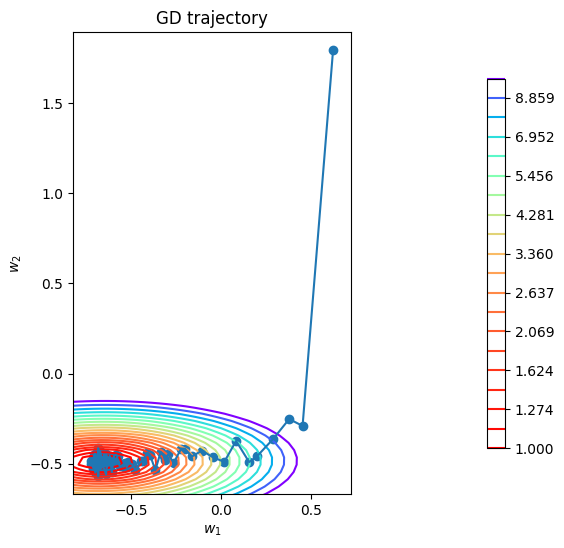

Шаг - 0.001, размер подвыборки - 41


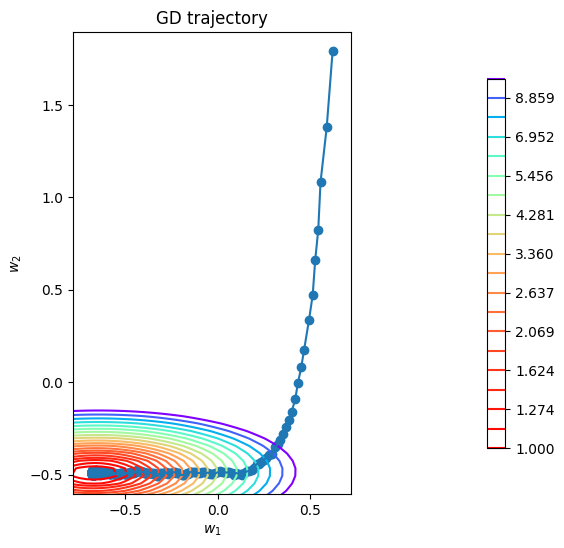

Шаг - 0.0005, размер подвыборки - 28


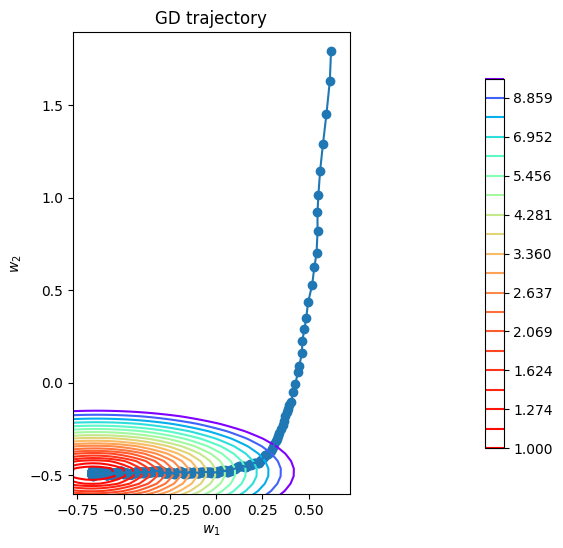

Шаг - 0.001, размер подвыборки - 39


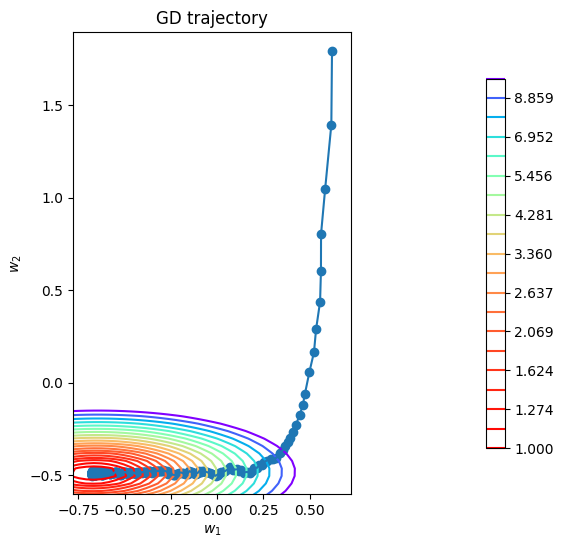

Шаг - 0.001, размер подвыборки - 100


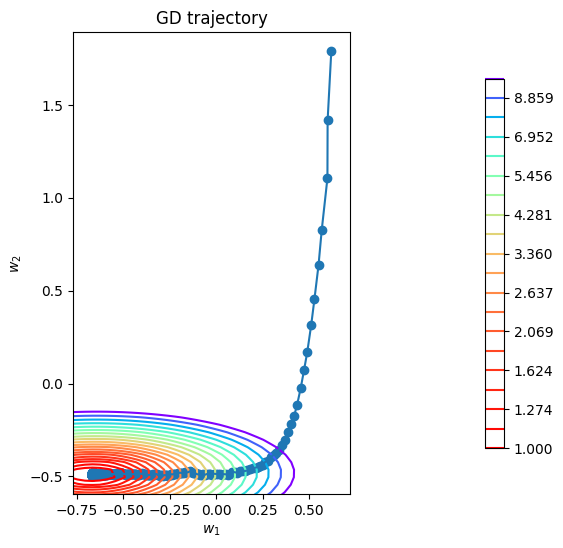

Шаг - 0.01, размер подвыборки - 108


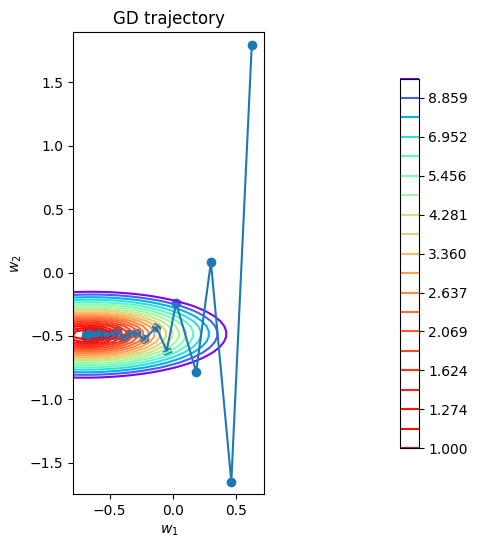

Шаг - 0.0007, размер подвыборки - 148


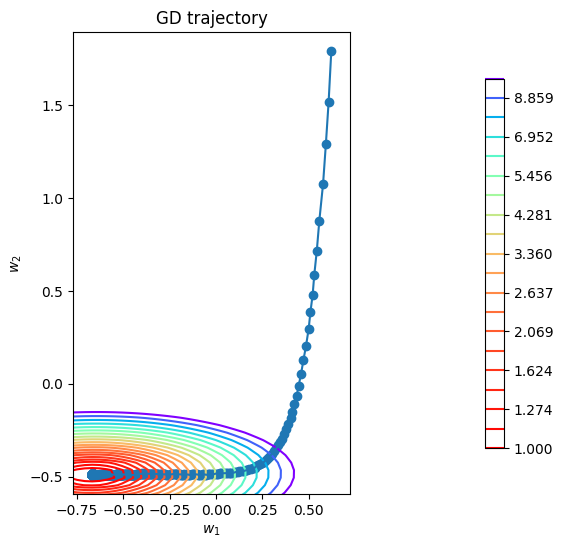

Шаг - 0.01, размер подвыборки - 117


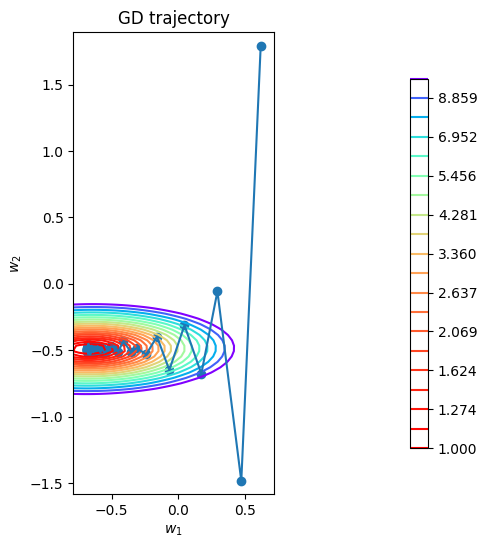

Шаг - 0.05, размер подвыборки - 68


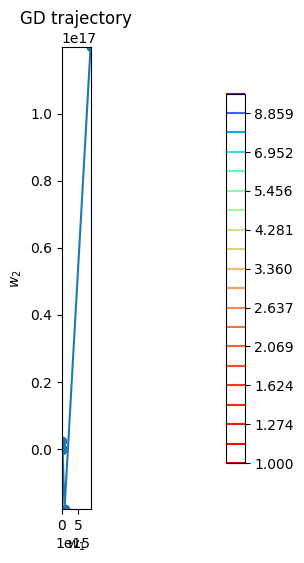

Шаг - 0.1, размер подвыборки - 44


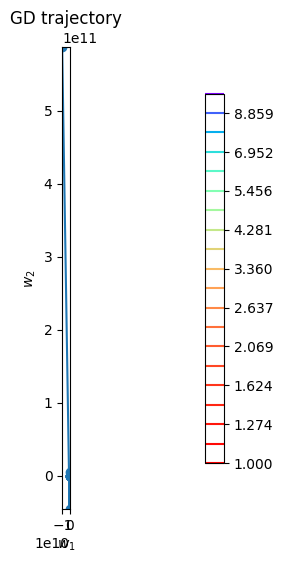

Шаг - 0.0001, размер подвыборки - 145


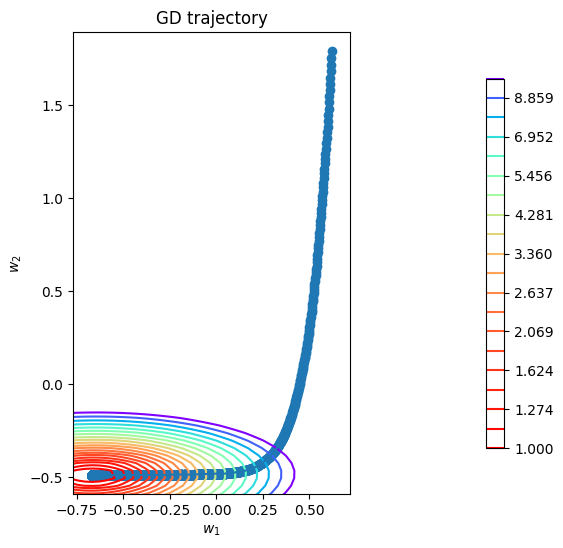

Шаг - 0.015, размер подвыборки - 135


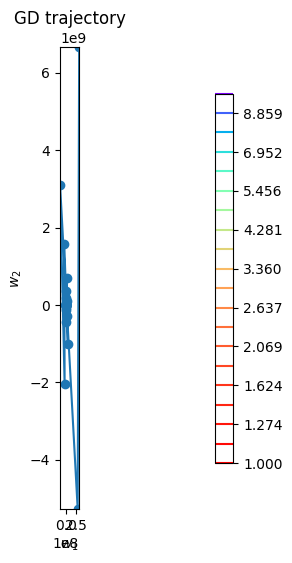

Шаг - 0.007, размер подвыборки - 132


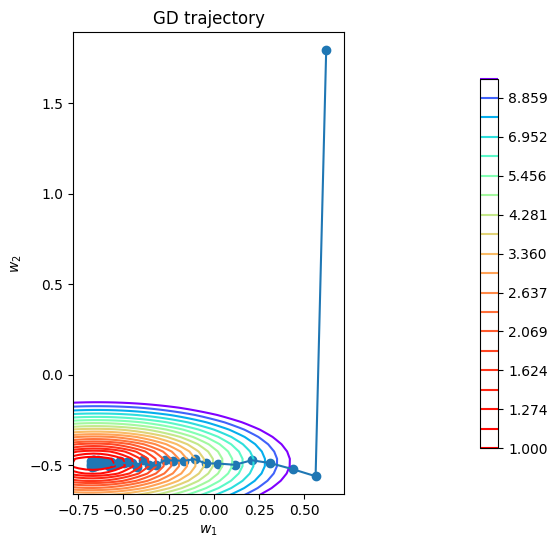

Шаг - 0.0035, размер подвыборки - 66


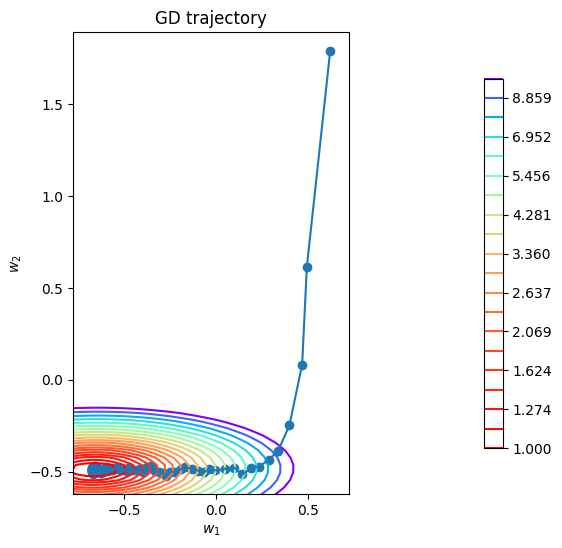

In [295]:
lr_massive = np.array([0.0001, 0.0005, 0.0007, 0.001, 0.001, 0.001, 0.0035, 0.005, 0.007, 0.01, 0.01, 0.015, 0.05, 0.1])
batch_size = np.random.choice(np.arange(150), size=len(lr_massive), replace=False)

np.random.shuffle(lr_massive)
np.random.shuffle(batch_size)

for kortez in zip(lr_massive, batch_size):
    lr, size_batch = kortez
    print(f'Шаг - {lr}, размер подвыборки - {size_batch}')
    w_spisok = stochastic_gradient_descent(w_init, X, y, loss, lr, size_batch, n_iterations=int(1/lr))
    plot_gd(w_spisok, X, y, loss)

__ОТВЕТ:__ хахаах ну по первой картинке заметно, что поведение довольно ощутимо отличается от полной версии градиентного спуска. Значительно влияние на траекторию спуска оказывает размер батча: если делать его слишком большим, то алгоритм приближается к классической версии и там уже ничего интересного нет, поэтому в рандомайзере я ограничил  генерации на 150. Сам же размер батча почти буквально задает траектории движения и если сделать батч недостаточно большим, то алгоритм начинает крайне сильно шатать, траектория становится зашумлённой, спуск кружит вокруг минимума

Размер шага, конечно, тоже влияет, но не так сильно как размер батча. Вообще там главное сделать его достаточно маленьким и тогда всё будет ок, ГД сходится довольно быстро, поэтому накинуть еще  пару десятков итераций не должно стать сильной проблемой если не хватило для схождения.

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [296]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w_list = [w_init.copy()]
    w_current = w_init.copy()
    
    for t in range(n_iterations):
        n_t = lr * (1 / (1 + t))**p
        batch = np.random.choice(X.shape[0], size=batch_size, replace=True)
        X_batch = X[batch]
        y_batch = y[batch]
        grad = loss.calc_grad(X_batch, y_batch, w_current)
        w_current = w_current - n_t * grad
        w_list.append(w_current)
        
    return w_list

Проверим работоспособность алгоритма

In [299]:
loss = MSELoss()
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.05, 100, p=0.65, n_iterations=100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))
# рабоет вроде, но чет резы конечно отстой

425.5891768045025
0.8801713649694329


**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

Текущий размер p - 0.1


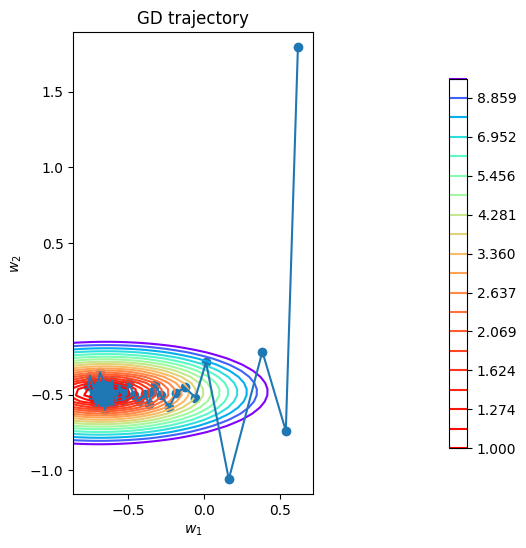

Текущий размер p - 0.15000000000000002


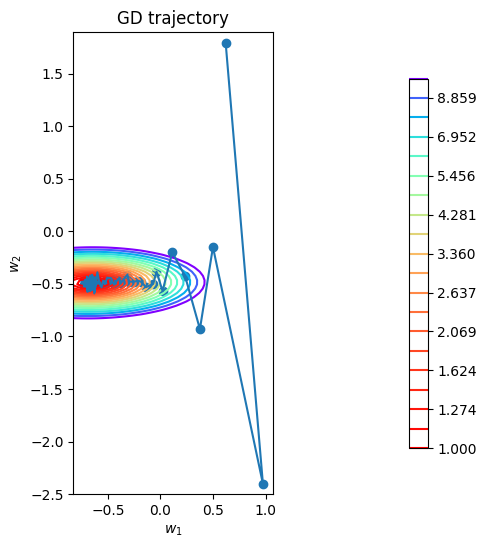

Текущий размер p - 0.20000000000000004


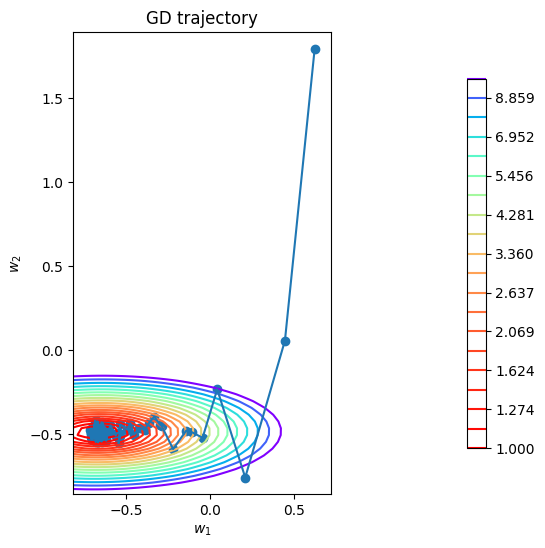

Текущий размер p - 0.25000000000000006


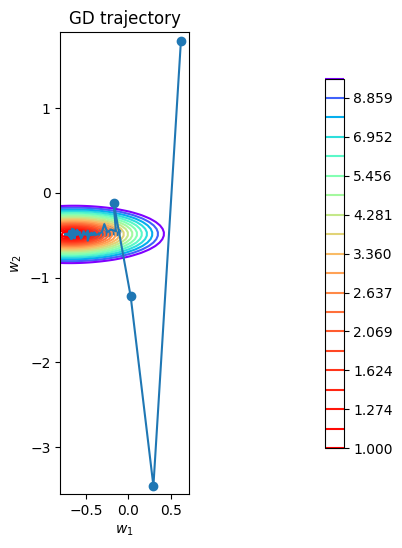

Текущий размер p - 0.30000000000000004


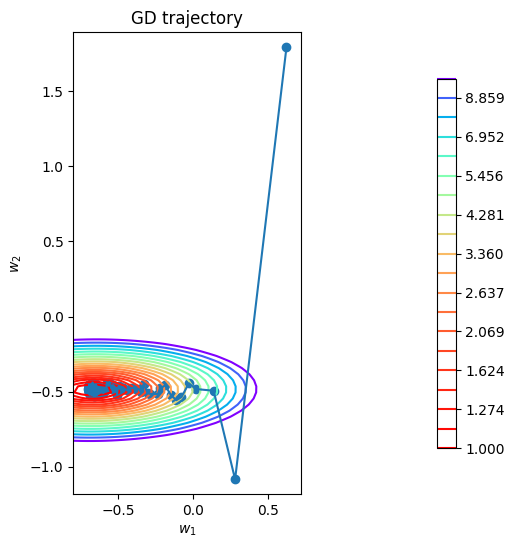

Текущий размер p - 0.3500000000000001


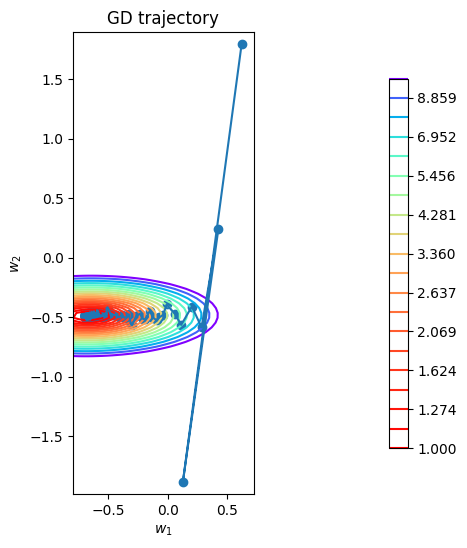

Текущий размер p - 0.40000000000000013


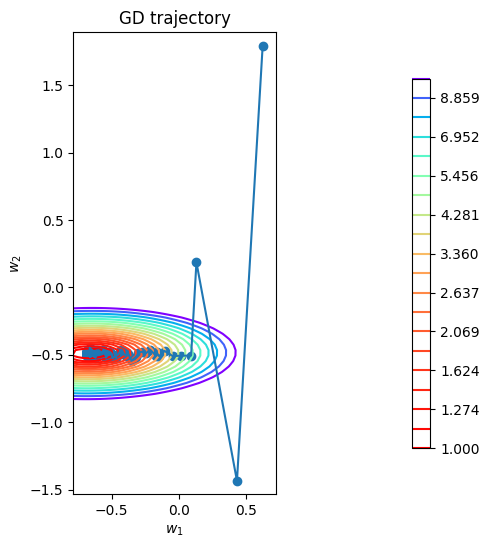

Текущий размер p - 0.45000000000000007


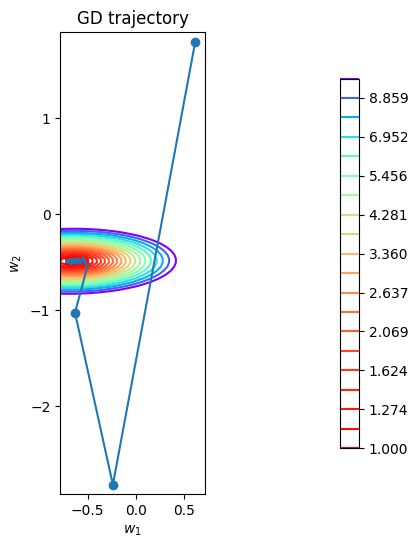

Текущий размер p - 0.5000000000000001


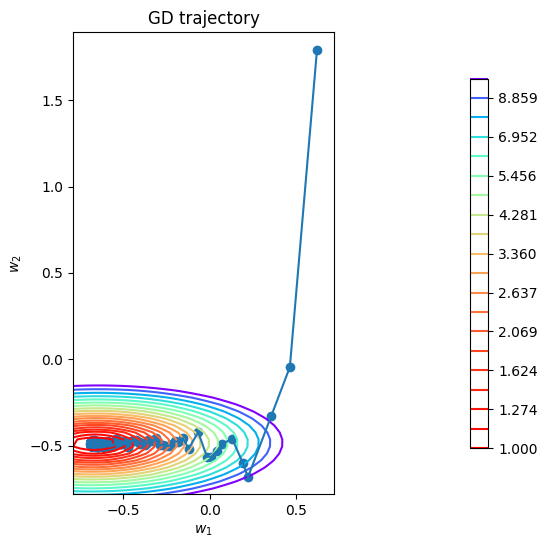

Текущий размер p - 0.5500000000000002


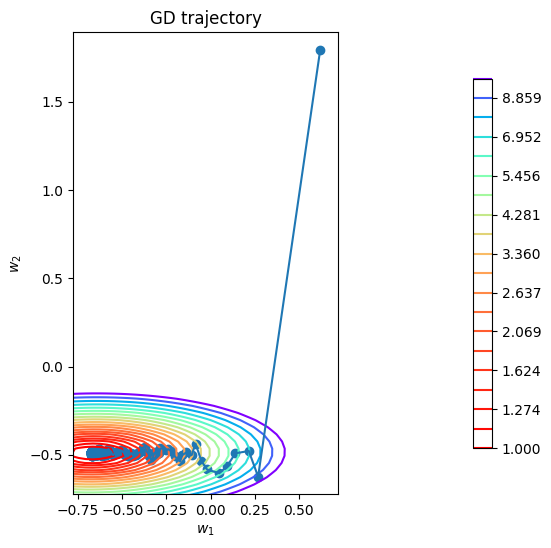

Текущий размер p - 0.6000000000000002


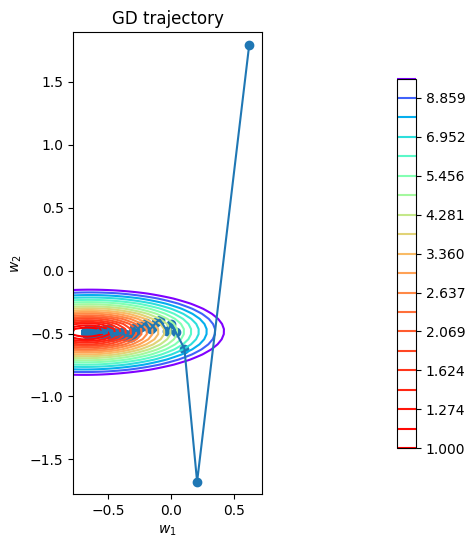

Текущий размер p - 0.6500000000000001


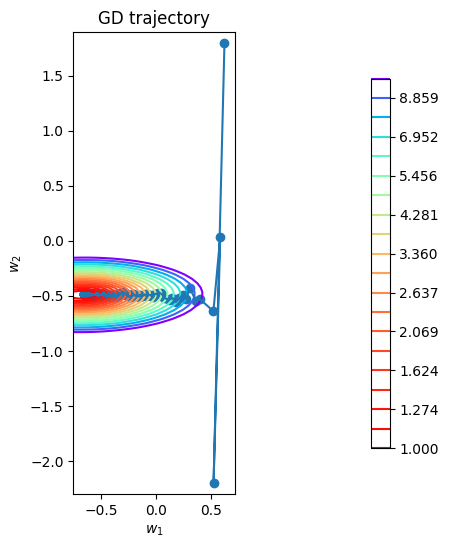

Текущий размер p - 0.7000000000000002


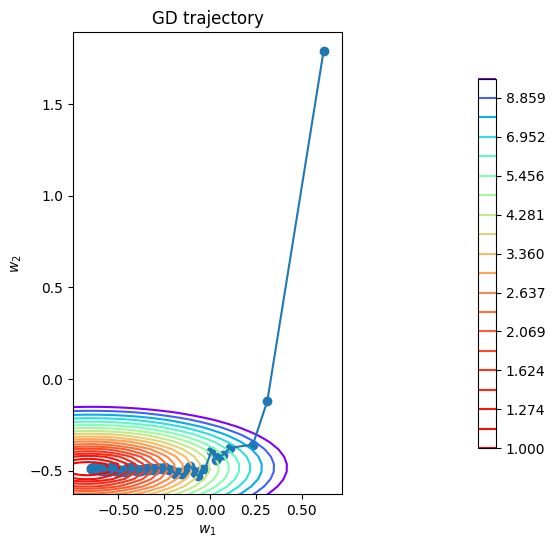

Текущий размер p - 0.7500000000000002


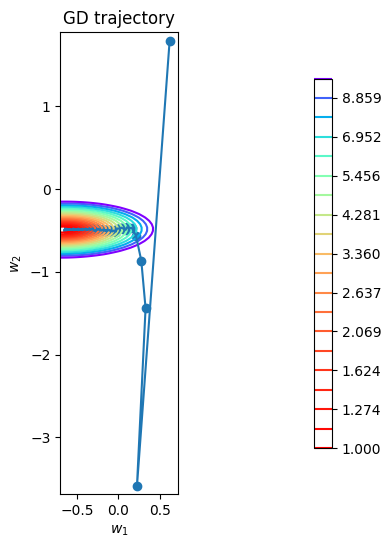

Текущий размер p - 0.8000000000000002


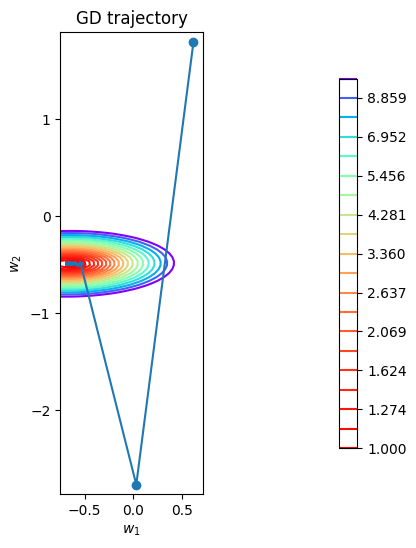

Текущий размер p - 0.8500000000000002


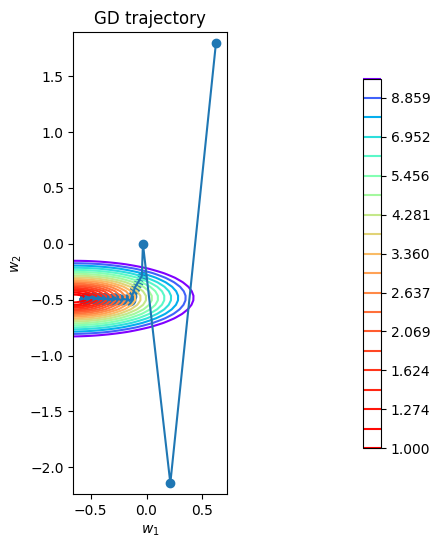

Текущий размер p - 0.9000000000000002


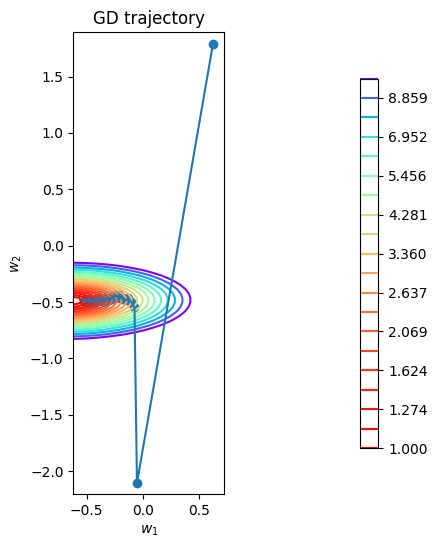

Текущий размер p - 0.9500000000000003


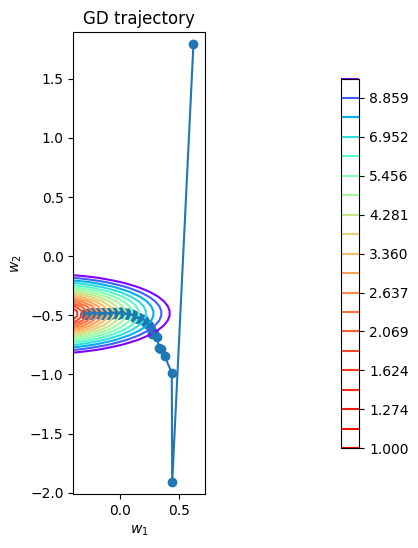

In [19]:
# from tqdm import tqdm

for p  in (np.arange(0.1, 1, 0.05)):
    w_spisok = stochastic_gradient_descent(w_init, X, y, loss, 0.01, batch_size=10, p=p)
    print(f'Текущий размер p - {p}')
    plot_gd(w_spisok, X, y, loss)

__ВЫВОД__: чем больше значение p, тем меньше становится шаг, соответствено тем меньше градинетный спуск шатает, траектори становится более плавной по мере приближения к минимуму, но при этом шаги становятся крайне малыми и возникает риск того, что спуск не сойдётся в минимум. Это хорошо видно на самых последних картинках, мы там тупо не дошли. А вот при маленьком значение p итоговое значение динамического шага будет достаточное для схождения, но колбасить около минимум нас будет будь здоров, об этом ярко свидетельствуют первые 3 картинки. Поэтому, как мне кажется, оптимальнее всего брать что-то посерединке.

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

Буду использовать последнюю реализацию стохастического градиентного спуска, т.е с затухающим динамическим шагом.

In [319]:
import matplotlib.pyplot as plt
import time

n_iterations = np.arange(1, 100) # всего буду делать 100 итераций
batch_size = 10
p = 0.5 # ну вот я так вижу, я так чувствую
lr = 0.01 # ну вот я опять так чувствую, как из предыдущего задания

loss = MSELoss()

loss_massive_fullGD = []
loss_massive_stohanGD = []
start = time.time()
for n in n_iterations:    
    fullGD_w_optimal = gradient_descent(w_init, X, y, loss, lr, n_iterations=n)[-1] # взял последние веса, самые оптимальные типа после спуска
    loss_massive_fullGD.append(loss.calc_loss(X, y, fullGD_w_optimal))
    
    stohanGD_w_optimal = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, p=0, n_iterations=n)[-1]
    loss_massive_stohanGD.append(loss.calc_loss(X, y, stohanGD_w_optimal)) 
    
end = time.time()
diff = end - start
print(diff)
    

0.0764000415802002


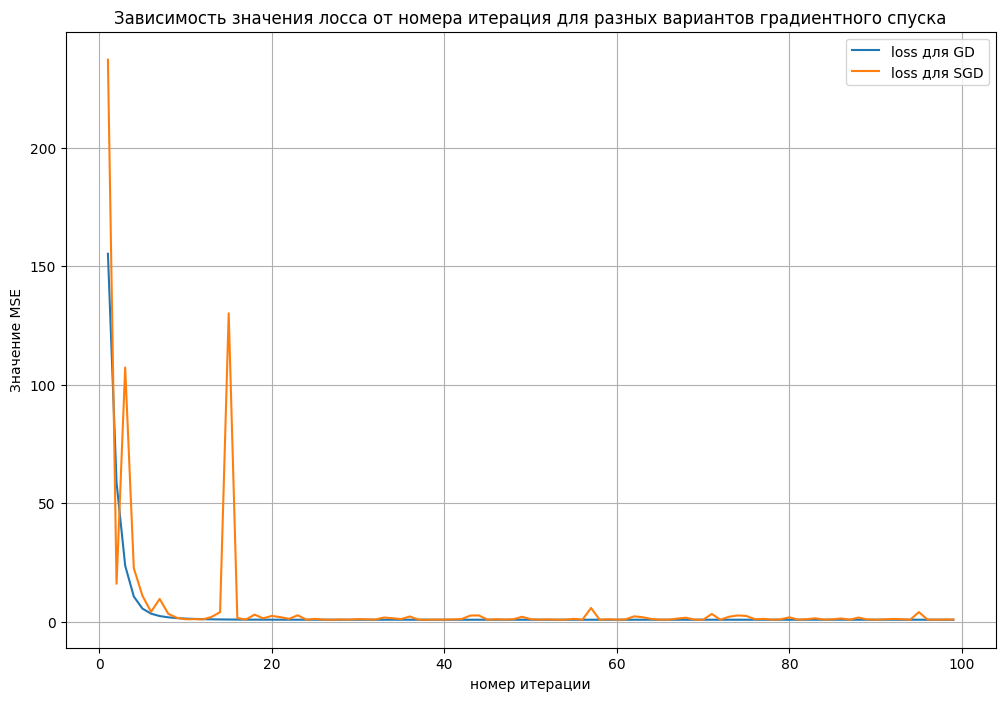

In [320]:
plt.figure(figsize=(12, 8))
plt.title('Зависимость значения лосса от номера итерация для разных вариантов градиентного спуска')
plt.plot(n_iterations, loss_massive_fullGD, label='loss для GD')
plt.plot(n_iterations, loss_massive_stohanGD, label='loss для SGD')
plt.ylabel('Значение MSE')
plt.xlabel('номер итерации')
plt.legend()
plt.grid()
plt.show()

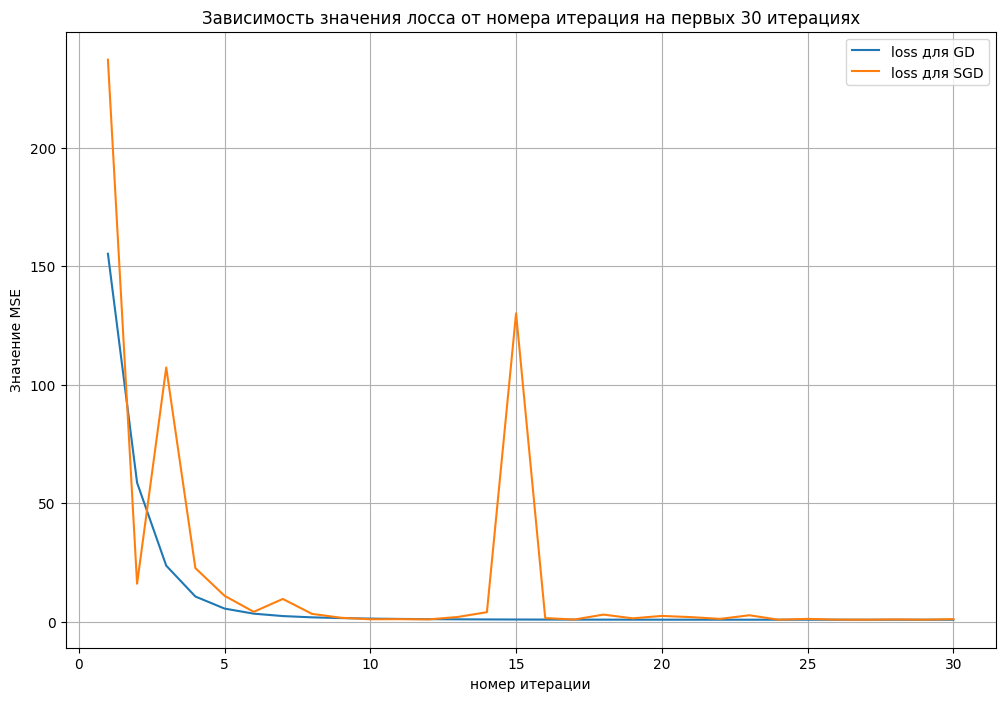

In [321]:
plt.figure(figsize=(12, 8))
plt.title('Зависимость значения лосса от номера итерация на первых 30 итерациях')
plt.plot(n_iterations[:30], loss_massive_fullGD[:30], label='loss для GD')
plt.plot(n_iterations[:30], loss_massive_stohanGD[:30], label='loss для SGD')
plt.ylabel('Значение MSE')
plt.xlabel('номер итерации')
plt.legend()
plt.grid()
plt.show()

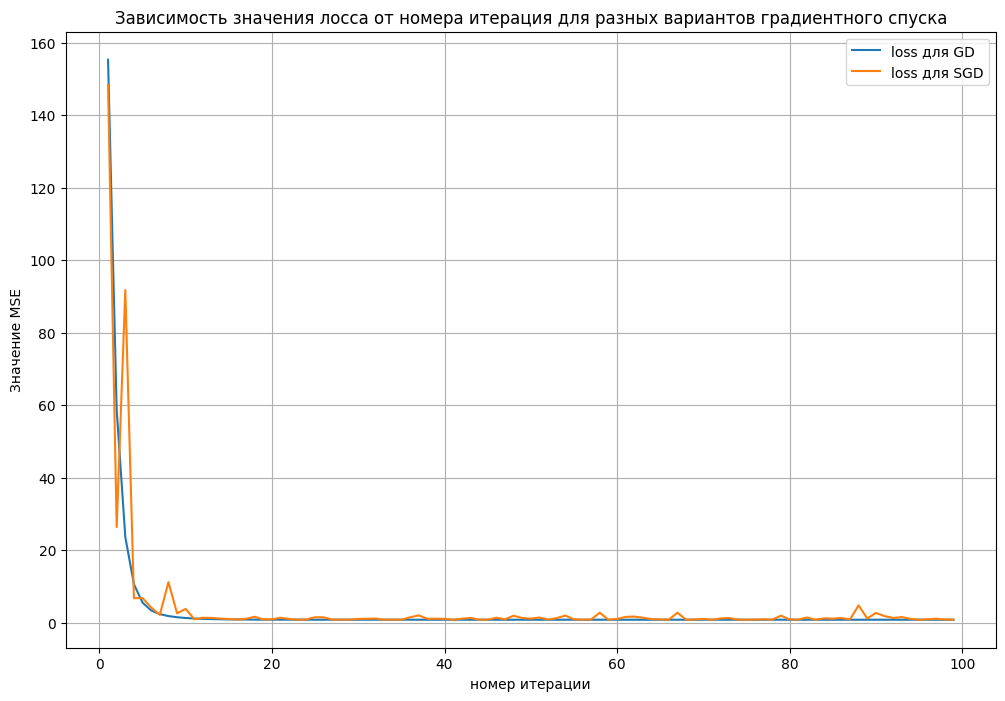

__ОТВЕТ:__ Не очень понимаю вопрос задания: преимущество SGD в чем? Преимущество SGD в том, что у него сильно ниже вычислительная сложность, чем у полного градиентного спуска при том, что он является несмещенной оценкой, этого на графике не видно (что вполне ожидаемо, график же не про это совсем). Но в то же время по этим графикам мы видим ряд "недостатков" SGD: если полному градиетному спуску до полного схождения в минимум потребовалось около 10 итераций и далее его совсем не шатает, то вот у SGD ситуация иная. Во-первых, у него довольно забавное начало спуска, т.к. в моменте ошибка и вовсе выросла. А во-ворых, как видно из второй картинке, его тракектория крайне нестабильная и даже после 75-80 итераций может просто колбасить вокруг минимума, из-за чего видны некоторые небольшие скачки у MSE.

На самой последней картинке я отдельно нарисовал зависимость MSE от итерации, но при отсутствии динамического шага, т.е. там p=0. Ну короче ниче не поменялось особо и SGD также шатает, а полный градиентный сходится в 0 по ошибке очень быстро.

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [322]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        w_init_linear = np.random.randint(y.min(), y.max(), size=X.shape[1]) # жоска инициализировал
        self.w = gradient_descent(w_init_linear, X, y, self.loss, self.lr)[-1]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        
        y_pred = np.dot(X, self.w)
        return y_pred

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [323]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [324]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [325]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

__WARNING__: т.к. там дальше будет задание, где необходимо подобрать параметрм регуляризации, а это гиперпараметр, то в этом задание я сделаю разбиение ещё и на валидационную выборку, чтобы потом по ней подбирать коэфф. Надеюсь, что такого маленького датасета хватит....

In [326]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
np.random.seed(52)
X_raw.columns = X_raw.columns.astype('str')

X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y, test_size=0.4, random_state=52)
x_val, x_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=52)

object_columns = X_train.select_dtypes(include='object').columns
not_object_columns = X_train.select_dtypes(exclude='object').columns
object_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), 
                                  ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))])
not_object_pipeline = Pipeline(steps=[('imputer', SimpleImputer()), ('scaled', StandardScaler())])

preprocessor = ColumnTransformer(transformers=[('object_pipeline', object_pipeline, object_columns), ('not_object_pipeline', not_object_pipeline, not_object_columns)])
pipeline = Pipeline(steps=[('pipeline', preprocessor)])


In [327]:
X_train = pipeline.fit_transform(X_train)
x_val = pipeline.transform(x_val)
x_test = pipeline.transform(x_test)

In [328]:
X_train.shape, x_test.shape, x_val.shape

((120, 71), (41, 71), (40, 71))

**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [329]:
linear_regression.fit(X_train, y_train)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [331]:
from sklearn.metrics import mean_squared_error as mse
np.random.seed(52)
y_pred_train = linear_regression.predict(X_train)
y_pred_test = linear_regression.predict(x_test)

print(f'Ошибка на обучающей: {round(mse(y_train, y_pred_train), 3)}')
print(f'Ошибка на тесте: {round(mse(y_test, y_pred_test), 3)}')

Ошибка на обучающей: 1382282.926
Ошибка на тесте: 51080472.114


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [332]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        loss = 1 / X.shape[0] * norm(np.dot(X, w) - y)**2 + self.coef * norm(w[:-1])**2 # Вычислите значение функции потерь при помощи X, y и w и верните его
        return loss
        
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # grad = 2 / X.shape[0] * X.T * (np.dot(X, w) - y) + 2*self.coef * w[:-1] # короче первое слагаемое это веектор
        # размерности d*1, поэтоум его нельзя просот сложить с w[:-1], значит возьмем [:-1] для самого ветктора градиента
        grad = 2 / X.shape[0]  * np.dot(X.T, (np.dot(X, w) - y))
        grad[:-1] = grad[:-1] + 2*self.coef * w[:-1]
        return grad
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [333]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

__РЕШЕНИЕ__: буду рисовать сравнение MSE на трейне и тесте при разных коэффициентах регуляризации, чтобы наглядно было понятно

In [334]:
from tqdm import tqdm

regulazations = np.linspace(0, 0.5, 50)

train_loss = []
validation_loss = []

for coef in tqdm(regulazations):
    linear_model = LinearRegression(MSEL2Loss(coef)).fit(X_train, y_train)
    y_pred_train = linear_model.predict(X_train)
    y_pred_validation = linear_model.predict(x_val)
    train_loss_score = mse(y_train, y_pred_train)
    validation_loss_score = mse(y_val, y_pred_validation)
    train_loss.append(train_loss_score)
    validation_loss.append(validation_loss_score)

100%|██████████| 50/50 [00:33<00:00,  1.48it/s]


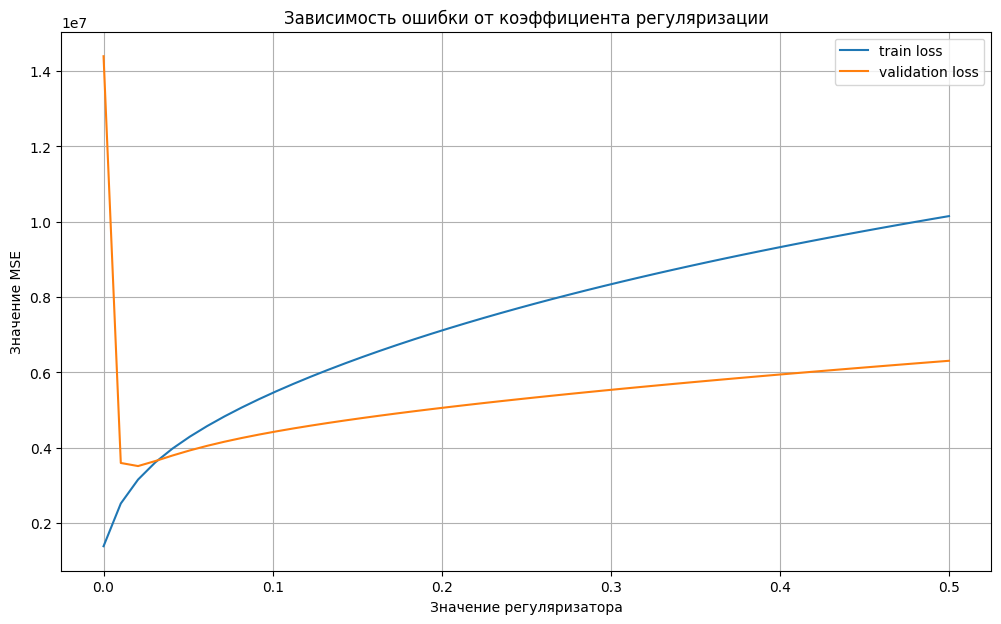

In [335]:
plt.figure(figsize=(12, 7))
plt.title('Зависимость ошибки от коэффициента регуляризации')

plt.plot(regulazations, train_loss, label='train loss')
plt.plot(regulazations, validation_loss, label='validation loss')

plt.ylabel('Значение MSE')
plt.xlabel('Значение регуляризатора')
plt.legend()
plt.grid()
plt.show()

Видно, что после +-0.03 ошибка и на валидационке, и на обучающей выборке начинает расти про увеличении коэффициента регуляризации. При этом где-то около 0.02 лосс на валидационной минимальный, а т.к. у нас мэин задача - добиться улучшения на тесте, то возьмем именно это значение для регуляризации. 

In [ ]:
X_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape

((120, 71), (40, 71), (41, 71), (120,), (40,), (160,))

In [337]:
X_train_linear = np.concatenate([X_train, x_val], axis=0) # сделал конкатенацию, чтобы обучать итоговую модельку абсолютно на всех трейн данных
y_train_linear = np.concatenate([y_train, y_val], axis=0)

In [340]:
linear_regulazation = LinearRegression(MSEL2Loss(0.02))
linear_regulazation.fit(X_train_linear, y_train_linear)
y_pred_train_regulazation = linear_regulazation.predict(X_train_linear)
y_pred_test_regulazation = linear_regulazation.predict(x_test)

__ПОБЕДАААААААААААААААААААААААА!!!!!!!!!!!!!!!!!!!!!!!!!!!__

In [341]:
print(f'Ошибка модели с регуляризацией на тестовой выборке составляет {round(mse(y_test, y_pred_test_regulazation), 3)}, а на обучающей - {round(mse(y_train_linear, y_pred_train_regulazation), 3)}.')

Ошибка модели с регуляризацией на тестовой выборке составляет 8297717.696, а на обучающей - 3116104.324.


__ОТВЕТ:__ Видно, что мы сократили лосс как на тестовой выборке, так и на обучающей. Я считаю это хорошим результатом, т.к. при валидации модель ни разу изначально не видела тестовую выбору, а по итогу в полтора раза снизили ошибку на обучающей и на +-5% на тесте, норм.

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [49]:
from numpy import sign

class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        y_pred = np.dot(X, w)
        y_diff = y_pred - y
        loss = np.where(np.abs(y_diff) < self.eps, 0.5 * y_diff**2, self.eps*(np.abs(y_diff) - 0.5 * self.eps))
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        return np.mean(loss)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        y_pred = np.dot(X, w)
        y_diff = y_pred - y
        grad = np.where(np.abs(y_diff) < self.eps, y_diff, self.eps * sign(y_diff))
        loss = np.dot(X.T, grad)
        return (loss) / X.shape[0]
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

божее а какой эпсилон брать ааааа...ладно, опять валидацию буду делать.

In [51]:
epsilon_massive = np.linspace(5, 7000, 150)

huber_trailoss = []
huber_valloss = []

for eps in tqdm(epsilon_massive):
    huber_lin = LinearRegression(HuberLoss(eps)).fit(X_train, y_train)
    y_pred_train_huber = huber_lin.predict(X_train)
    y_pred_val_huber = huber_lin.predict(x_val)
    loss_train = mse(y_train, y_pred_train_huber)
    loss_val = mse(y_val, y_pred_val_huber)
    huber_trailoss.append(loss_train)
    huber_valloss.append(loss_val) 

100%|██████████| 150/150 [05:27<00:00,  2.18s/it]


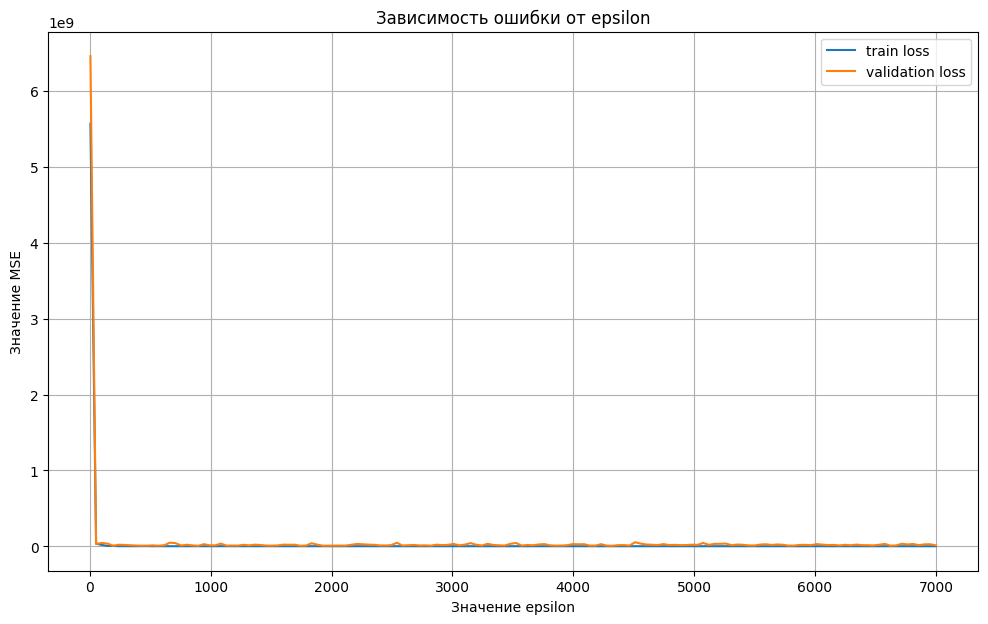

In [55]:
plt.figure(figsize=(12, 7))
plt.title('Зависимость ошибки от epsilon')

plt.plot(epsilon_massive, huber_trailoss, label='train loss')
plt.plot(epsilon_massive, huber_valloss, label='validation loss')

plt.ylabel('Значение MSE')
plt.xlabel('Значение epsilon')
plt.legend()
plt.grid()
plt.show()

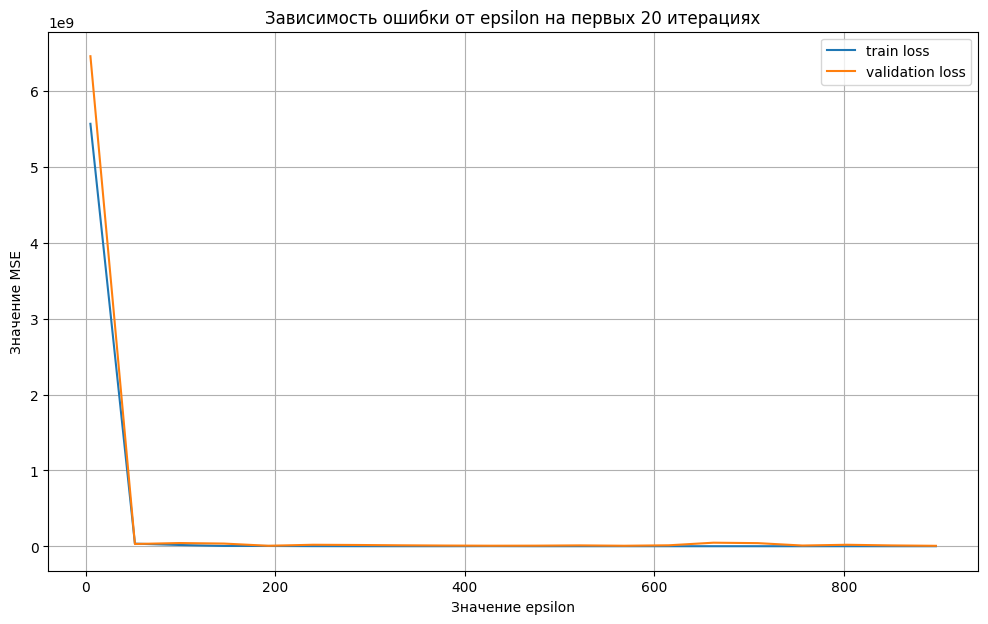

In [57]:
plt.figure(figsize=(12, 7))
plt.title('Зависимость ошибки от epsilon на первых 20 итерациях')

plt.plot(epsilon_massive[:20], huber_trailoss[:20], label='train loss')
plt.plot(epsilon_massive[:20], huber_valloss[:20], label='validation loss')

plt.ylabel('Значение MSE')
plt.xlabel('Значение epsilon')
plt.legend()
plt.grid()
plt.show()

__ВЫВОД:__ видно, что минимум лосса мы достигнем, когда $\epsilon$ будет больше +-50. Покажу это на конкретных примерах, т.е. обучу три модели: с эпсилон 5, 50, и 400, замерим ошибку и сравним с регрессией на обычной MSE.

In [95]:
epsilons = [5, 50, 400, 700]

X_train = np.concatenate([X_train, x_val])
y_train = np.concatenate([np.array(y_train.values), np.array(y_val.values)])

for num in epsilons:
    huber_lin = LinearRegression(HuberLoss(num)).fit(X_train, y_train)
    y_pred_train_huber = huber_lin.predict(X_train)
    y_pred_test_huber = huber_lin.predict(x_test)
    print(f'Ошибка на обучающей {round(mse(y_train, y_pred_train_huber), 3)}, на тестовой {round(mse(y_test, y_pred_test_huber), 3)}')

Ошибка на обучающей 14814293106.602, нв тестовой 23848767469.138
Ошибка на обучающей 92683303.859, нв тестовой 358136850.385
Ошибка на обучающей 2910658.726, нв тестовой 69289398.067
Ошибка на обучающей 2144065.666, нв тестовой 74034722.052


__ОТВЕТ:__ Ну в общем я не знаю, в чем заключается проблема...то ли у меня какая-то валидация неправильно реализованная, то ли обучаю неправильно, то ли хуберр лосс работает неверно, но по итогу у меня с использованием Хубер-лосса всё равно получается сильное переобучение. Да, оно заметно уменьшается по мере корректной подборки гиперпараметра, но это всё ещё сильно хуже, чем при использовании регуляризации и обычной MSE. Особенно это видно на тесте: там ошибки в пару десятков раз выше при использовании Хуберр лосса.

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

__БОМБАРДИРО КРОКОДИЛО__

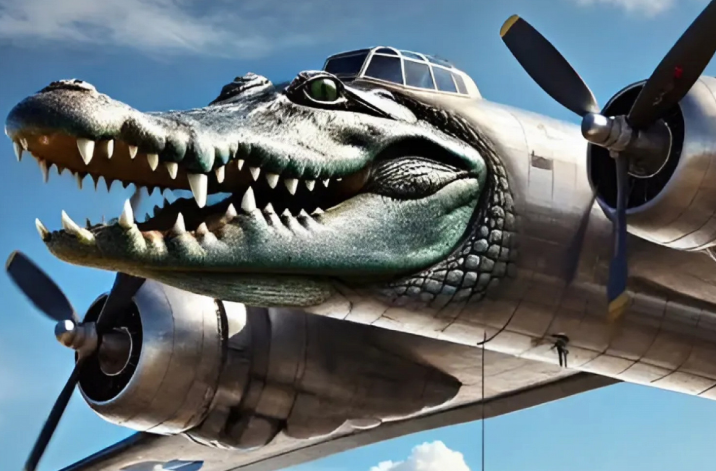

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

__РЕШЕНИЕ:__ так как тут будут какие-то эксперименты с параметром распределения, то буду реализовывать просто функцию (как мы делали раньше для градиентных спусков) и потом жестко тестить.

При исследование интернета было выяснено, что латунь (буду отжигать латунь) отжигают при +-700 (верхняя планка)
https://lib-metal.ru/lat/lattechnologprop.htm источник
Поэтому первоначальная температура будет у меня такой.

Также отмечу, что если у нас новые веса оказались не очень (ну то есть мсе выросла), то буду гененировать из равномерного распределения некоторую вероятность относительно которой мы будем принимать решение: принимать ли новые веса даже если они плохие.

In [342]:
from typing import Union

def simulated_annealing(X: Union[pd.DataFrame, np.array] , y: Union[pd.DataFrame, np.array], w_init: np.array, loss_funcion: BaseLoss,
                        T: int | float, alpha: float = 0.99, n_iterations: int = 1000):
    '''
    Вкуснейшая функция для имиитацции отжига.
    X - матрица объекты признаки
    y - правильные ответы
    w - первоначальные веса
    loss_function - функция потерь, умеющая в градиент и в вычисление ошибки
    T - первоначальное значение температуры
    alpha - коэффициент охлаждения
    '''
    # T_history = [T]
    count_2 = 0 
    w_current = w_init.copy()
    w_massive = [w_init.copy()] # буду сохранять историю весов
    current_loss = loss_funcion.calc_loss(X, y, w_current)
    loss_massive = [loss_funcion.calc_loss(X, y, w=w_init)] # буду сохранять историю лоссов
    for _ in tqdm(range(n_iterations)):
        w_new = w_current + np.random.standard_t(3, size=w_current.shape)
        new_loss = loss_funcion.calc_loss(X, y, w_new)
        diff_loss = new_loss - current_loss
        if diff_loss < 0:
            w_current = w_new
            current_loss = new_loss
        else:
            probability = np.exp(-np.clip(diff_loss / T, -500, 500)) # стратегически честно признаюсь, что с clip мне подсказал гпт, потому что у мен
            # не очень частно, но всё же порой возникали переполнения
            if np.random.rand() <= probability:
                w_current = w_new
                current_loss = new_loss
                count_2 +=1
            else:
                pass
        # T_history.append(T)
        T = T * alpha
        loss_massive.append(current_loss)
        w_massive.append(w_current)
    # print(count_2) сколько раз вероятностно приняли плохое решение
    return w_massive, loss_massive  

Проверим работоспособность на простой оптимизации MSE.

In [343]:
# заново проделаем рандомную генерацию массивов, потмоу что уже перезаписал в какие-то переменные что то другое

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

# print(X.shape)
# print(y.shape)

In [350]:
loss = MSELoss()
result = simulated_annealing(X, y, w_init, loss, T=700, alpha=0.99, n_iterations=1000)
w, losssss= result[0], result[1] 
# w[-1], losssss[-1], losssss[0]
print(f'Финальный лосс MSE после нашего отжига {round(losssss[-1], 3)}. Это идеально схоже с оптимизацей через градиентный спуск')

100%|██████████| 1000/1000 [00:00<00:00, 111720.00it/s]

Финальный лосс MSE после нашего отжига 0.889. Это идеально схоже с оптимизацей через градиентный спуск


По поводу траектории, думаю, комментарии не нужны :)

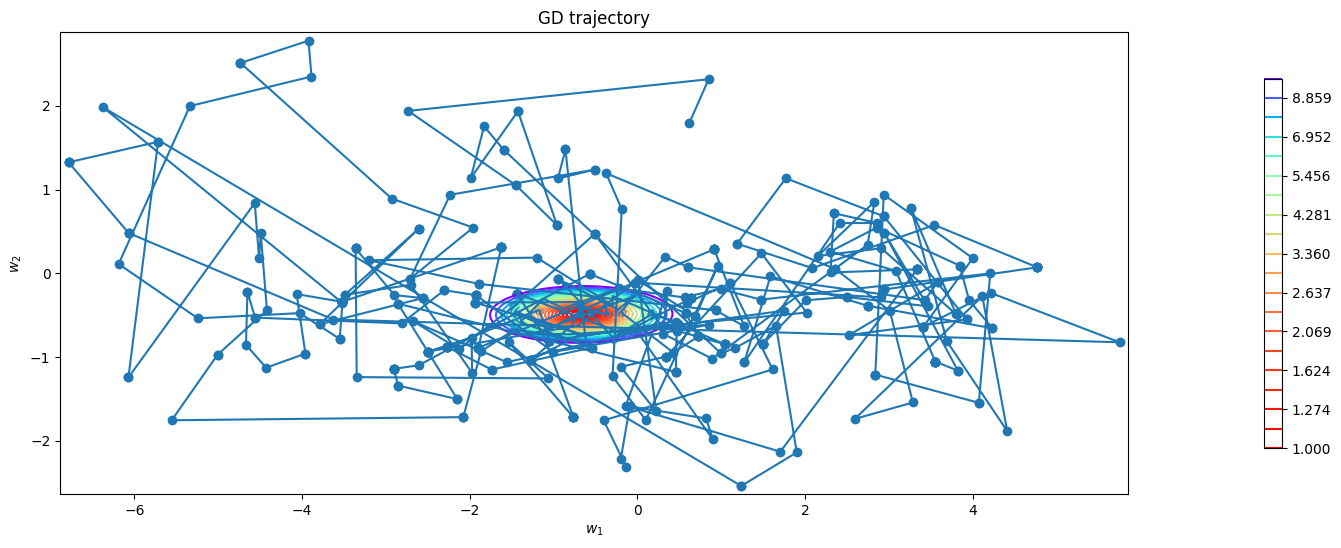

In [351]:
plot_gd(w, X, y, loss)

А теперь попробуем на боевом оптимизировать веса для нашей регресии для датасета про машинки

In [352]:
np.random.seed(13) # всё крайне сильно зависит от зерна, можно поиграться и добиться ошибки в сто миллионов
w_init_cars = np.random.rand(X_train.shape[1])
cars_result = simulated_annealing(X_train, y_train, w_init_cars, loss, 1000, 0.99, 100000) # также дополнительно увеличил количество
# итераций, при 1000 этого явно не хватало, параметров видимо многоватов уже для 1000 итераций
print(f'Ошибка на обучающей выборке {round(cars_result[1][-1], 3)}')
print(f'Ошибка на тестовой выборке при таких парамеррах, обученных через отжиг {round(mse(y_test , np.dot(x_test, cars_result[0][-1])))}')

 69%|██████▉   | 69216/100000 [00:03<00:01, 22518.79it/s]C:\Users\levch\AppData\Local\Temp\ipykernel_21128\1020132121.py:28: RuntimeWarning: overflow encountered in scalar divide
  probability = np.exp(-np.clip(diff_loss / T, -500, 500)) # стратегически честно признаюсь, что с clip мне подсказал гпт, потому что у мен
100%|██████████| 100000/100000 [00:04<00:00, 21990.45it/s]

Ошибка на обучающей выборке 1447443.231
Ошибка на тестовой выборке при таких парамеррах, обученных через отжиг 8325942


Получилось столько же, сколько при использовании регуляризации. Но, повторюсь, очень всё зависит от зерна и количества итераций, не говоря уже о методе понижения температуры или генерации новых весов. Очень крутая домашка!